In [1]:
"..."

'...'

In [ ]:
import torch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

def create_scheduler(
    optimizer, 
    total_epochs: int, 
    warmup_epochs: int = 10, 
    min_lr: float = 1e-6
):
    warmup_scheduler = LinearLR(
        optimizer, 
        start_factor=1e-8, 
        end_factor=1.0, 
        total_iters=warmup_epochs
    )
    
    cosine_scheduler = CosineAnnealingLR(
        optimizer, 
        T_max=(total_epochs - warmup_epochs), 
        eta_min=min_lr
    )
    
    scheduler = SequentialLR(
        optimizer, 
        schedulers=[warmup_scheduler, cosine_scheduler], 
        milestones=[warmup_epochs]
    )
    
    return scheduler

In [ ]:
import torch
from lightning.pytorch.callbacks import Callback

class VisualLoggingCallback(Callback):
    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0):
        # Only log for the first batch of the validation epoch
        if batch_idx == 0:
            img_input, img_target = batch
            
            # Switch to eval mode for prediction
            pl_module.eval()
            with torch.no_grad():
                img_pred = pl_module(img_input.to(pl_module.device))
            pl_module.train()

            # Create a grid: Input, Prediction, and Target side-by-side
            # (Assumes images are normalized; you might need to un-normalize)
            comparison = torch.cat([img_input[:4], img_pred[:4], img_target[:4]], dim=3)
            
            # Log to your preferred logger (e.g., TensorBoard or WandB)
            trainer.logger.experiment.add_images('Visual_Progress', comparison, trainer.global_step)

# Add it to your Trainer
# trainer = L.Trainer(callbacks=[VisualLoggingCallback()])

In [3]:
import torch
import torch.nn.functional as F
import lightning as L
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

class Image2ImageModel(L.LightningModule):
    def __init__(self, model, lr=1e-4):
        super().__init__()
        self.model = model  # e.g., a timm model or custom UNet
        self.lr = lr
        
        # Metrics for I2I are specialized
        self.psnr = PeakSignalNoiseRatio()
        self.ssim = StructuralSimilarityIndexMeasure()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        # 1. Prepare Data (Input -> Target)
        img_input, img_target = batch 
        
        # 2. Forward Pass
        img_pred = self(img_input)
        
        # 3. Calculate Loss (MSE or L1 are standard for I2I)
        loss = F.mse_loss(img_pred, img_target)
        
        # 4. Logging
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img_input, img_target = batch
        img_pred = self(img_input)
        
        val_loss = F.mse_loss(img_pred, img_target)
        
        # Update and Log Metrics
        self.psnr(img_pred, img_target)
        self.ssim(img_pred, img_target)
        
        self.log("val_loss", val_loss, prog_bar=True)
        self.log("val_psnr", self.psnr, on_epoch=True)
        self.log("val_ssim", self.ssim, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    


In [ ]:
import time
import torch
import torch.nn.functional as F
import torchvision
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter

def validate(model, val_loader, device, scaler, epoch, writer=None):
    model.eval()
    running_loss = 0.0
    n = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            x, y = batch
            x, y = x.to(device), y.to(device)
            
            with torch.amp.autocast("cuda", enabled=scaler.is_enabled()):
                y_pred = model(x)
                loss = F.mse_loss(y_pred, y, reduction="sum")
                
            running_loss += loss.item()
            n += x.size(0)
            
            # Replaces your VisualLoggingCallback: Log first batch to TensorBoard
            if batch_idx == 0 and writer is not None:
                num_imgs = min(4, x.size(0))
                # Concatenate Input, Prediction, and Target side-by-side
                comparison = torch.cat([x[:num_imgs], y_pred[:num_imgs], y[:num_imgs]], dim=3)
                
                # Un-normalize from [-1, 1] back to [0, 1] for visual logging
                comparison = (comparison * 0.5) + 0.5
                comparison = torch.clamp(comparison, 0, 1)
                
                grid = torchvision.utils.make_grid(comparison, nrow=1)
                writer.add_image('Visual_Progress', grid, epoch)

    model.train()
    return running_loss / max(n, 1)

def one_step(batch, model, device, scaler, grad_accum_steps):
    x, y = batch
    x, y = x.to(device), y.to(device)

    with torch.amp.autocast("cuda", enabled=scaler.is_enabled()):
        y_pred = model(x)
        loss = F.mse_loss(y_pred, y) / grad_accum_steps

    scaler.scale(loss).backward()
    
    # Returns the standard float value
    return loss.item() * grad_accum_steps

def train(
    model,
    train_loader,
    val_loader,
    epochs: int = 20,
    lr: float = 1e-4,
    device=None,
    grad_accum_steps: int = 1,
    amp: bool = True,
    scheduler_factory=None,
    checkpoint_path: str = "checkpoint.pt",
    validate_every: int = 1,
    log_dir: str = "runs/experiment" # Added for TensorBoard
):
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    scheduler = scheduler_factory(optimizer) if scheduler_factory is not None else None
    scaler = torch.amp.GradScaler('cuda', enabled=(amp and device.type == "cuda"))
    
    writer = SummaryWriter(log_dir=log_dir)

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}/{epochs}")
        
        optimizer.zero_grad()

        for i, batch in pbar:
            # FIX: one_step already returns a float, no need for .item()
            loss_val = one_step(batch, model, device, scaler, grad_accum_steps)

            if (i + 1) % grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            running_loss += loss_val
            pbar.set_postfix(train_loss=running_loss / (i + 1))
            
        if len(train_loader) % grad_accum_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        if scheduler is not None:
            try:
                scheduler.step()
            except Exception:
                pass

        val_loss = None
        if epoch % validate_every == 0 and val_loader is not None:
            val_loss = validate(model, val_loader, device, scaler, epoch, writer)
            writer.add_scalar('Loss/val', val_loss, epoch)
            
        writer.add_scalar('Loss/train', running_loss / len(train_loader), epoch)

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        }, checkpoint_path)

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch} done in {epoch_time:.1f}s, train_loss={running_loss/len(train_loader):.6f}"
              + (f", val_loss={val_loss:.6f}" if val_loss is not None else ""))
              
    writer.close()

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# 5. Example of iterating through the data
for batch_idx, (images, labels) in enumerate(trainloader):
    print(f"Batch {batch_idx+1}")
    print(f"Image tensor shape: {images.shape}") # Expected: [64, 3, 32, 32]
    print(f"Labels tensor shape: {labels.shape}") # Expected: [64]
    
    # Break after the first batch just for demonstration
    break


100%|██████████| 170M/170M [00:15<00:00, 11.1MB/s] 
/home/daniel/home/sph_encoder/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batch 1
Image tensor shape: torch.Size([64, 3, 32, 32])
Labels tensor shape: torch.Size([64])


In [ ]:
from  models.vit import Model

batch_size = 2

img_size = 256
patch_size = 16
in_channels = 3
hidden_dim = 512
latent_channels = 256
num_classes = 1000
num_heads = 8
depth = 8

model = Model(
    img_size=img_size, 
    patch_size=patch_size, 
    in_channels=in_channels, 
    hidden_dim=hidden_dim, 
    latent_channels=latent_channels,
    num_classes=num_classes,
    num_heads=num_heads,
    depth=depth,
)

In [ ]:
total_epochs = 1000

scheduler_factory = lambda opt: create_scheduler(
    opt, 
    total_epochs=total_epochs, 
    warmup_epochs=10, 
    min_lr=1e-6 # Or 1e-6
)


In [ ]:
train(
    model=model,
    train_loader=trainloader,
    val_loader=testloader,
    epochs=total_epochs,
    lr=1e-4,
    device=None,
    grad_accum_steps=1,
    amp=True,
    scheduler_factory=scheduler_factory,
    checkpoint_path="checkpoint.pt",
    validate_every=1,
)

## other

In [ ]:
import torch
with torch.no_grad():
    model.eval()
    x = model(torch.Tensor([1]), None)

: 

In [ ]:
for i in range(3):
    print(f"{x[0, i].mean(), x[0, i].std()}")

(tensor(0.0002), tensor(0.0125))
(tensor(5.8165e-05), tensor(0.0113))
(tensor(0.0002), tensor(0.0113))


: 

tensor([[[[ 5.5643e-03, -6.1909e-03, -1.1529e-03,  ..., -2.2901e-02,
           -1.8720e-02,  1.1180e-02],
          [ 1.2727e-02,  1.2670e-02,  1.0471e-02,  ...,  2.0554e-02,
            2.4076e-02, -6.5580e-03],
          [ 8.6439e-03, -6.7052e-03,  9.5893e-03,  ...,  4.9106e-03,
           -6.3136e-03,  5.1572e-03],
          ...,
          [ 1.2315e-02,  1.8214e-03,  6.5230e-03,  ..., -1.5935e-02,
           -2.9027e-03, -1.3718e-02],
          [-5.0769e-03,  9.4487e-04, -3.8220e-03,  ..., -1.0586e-02,
            8.6429e-03,  1.9827e-03],
          [ 1.9413e-03,  5.7372e-03,  1.4282e-02,  ...,  1.4252e-02,
            6.7401e-03,  1.7481e-02]],

         [[ 8.8139e-03,  4.0303e-03,  9.6470e-03,  ..., -3.4403e-05,
           -2.5785e-03, -5.4941e-03],
          [-3.8989e-03, -7.3629e-03, -1.5634e-02,  ...,  1.8961e-02,
            1.8224e-02, -3.8053e-03],
          [ 2.6392e-03,  9.0837e-03,  4.7410e-03,  ..., -2.4516e-03,
            6.4128e-03, -1.7196e-03],
          ...,
     

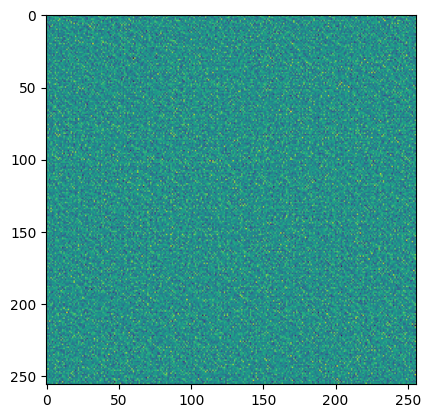

: 

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x[0].permute(1, 2, 0).detach().numpy()[:, :, 2])
x

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.059703622..0.052880876].


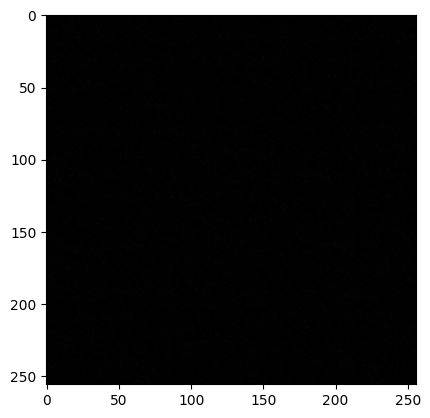

: 

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x[0].permute(1, 2, 0).detach().numpy())